In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

In [2]:
import os

blurred_path = r"dataset/blurred/archive/val2017_blurred_deterministic"
original_path = r"dataset/original/val2017"

print("Blurred folder exists:", os.path.exists(blurred_path))
print("Original folder exists:", os.path.exists(original_path))

print("Blurred sample files:", os.listdir(blurred_path)[:5])
print("Original sample files:", os.listdir(original_path)[:5])

Blurred folder exists: True
Original folder exists: True
Blurred sample files: ['000000000139.jpg', '000000000285.jpg', '000000000632.jpg', '000000000724.jpg', '000000000776.jpg']
Original sample files: ['000000000139.jpg', '000000000285.jpg', '000000000632.jpg', '000000000724.jpg', '000000000776.jpg']


Blurred exists: True
Original exists: True
Blurred shape: (426, 640, 3)
Original shape: (426, 640, 3)


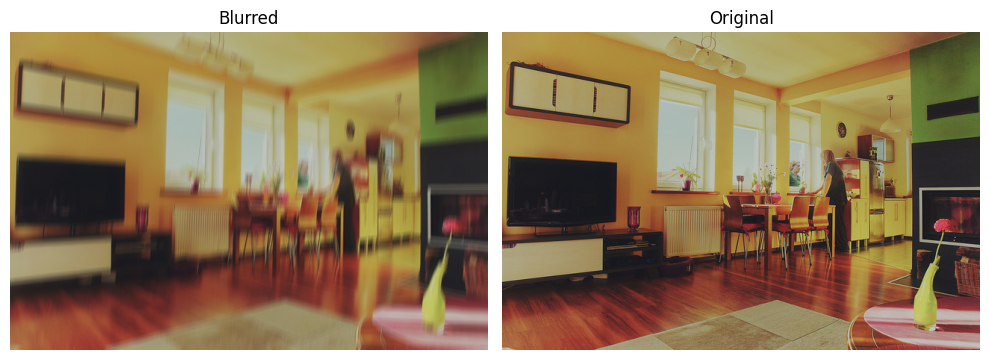

In [3]:
import cv2
import matplotlib.pyplot as plt
import os

img_name = "000000000139.jpg"

blurred_img_path = os.path.join(blurred_path, img_name)
original_img_path = os.path.join(original_path, img_name)

print("Blurred exists:", os.path.exists(blurred_img_path))
print("Original exists:", os.path.exists(original_img_path))

blurred_img = cv2.imread(blurred_img_path)
original_img = cv2.imread(original_img_path)

print("Blurred shape:", blurred_img.shape if blurred_img is not None else None)
print("Original shape:", original_img.shape if original_img is not None else None)

blurred_img_rgb = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2RGB)
original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(blurred_img_rgb)
plt.title("Blurred")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(original_img_rgb)
plt.title("Original")
plt.axis("off")

plt.tight_layout()
plt.show()

Saved Gaussian image to: results/deblur\gaussian_000000000139.jpg


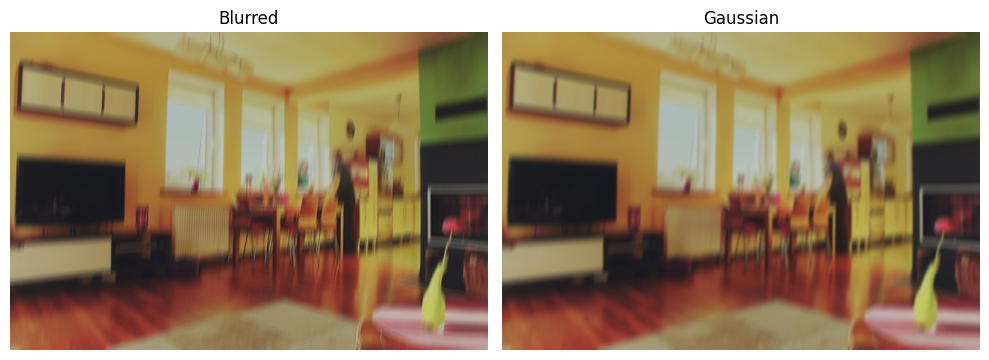

In [4]:
import os
import cv2
import matplotlib.pyplot as plt

blurred_path = r"dataset/blurred/archive/val2017_blurred_deterministic"
save_path = r"results/deblur"
os.makedirs(save_path, exist_ok=True)

img_name = "000000000139.jpg"
img_path = os.path.join(blurred_path, img_name)

# read blurred image
blurred_img = cv2.imread(img_path)
blurred_img_rgb = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2RGB)

# Gaussian baseline
gaussian_img = cv2.GaussianBlur(blurred_img, (5, 5), 0)
gaussian_img_rgb = cv2.cvtColor(gaussian_img, cv2.COLOR_BGR2RGB)

# save result
gaussian_save_path = os.path.join(save_path, "gaussian_" + img_name)
cv2.imwrite(gaussian_save_path, gaussian_img)

print("Saved Gaussian image to:", gaussian_save_path)

# show both
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(blurred_img_rgb)
plt.title("Blurred")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gaussian_img_rgb)
plt.title("Gaussian")
plt.axis("off")

plt.tight_layout()
plt.show()

Saved Wiener image to: results/deblur\wiener_000000000139.jpg


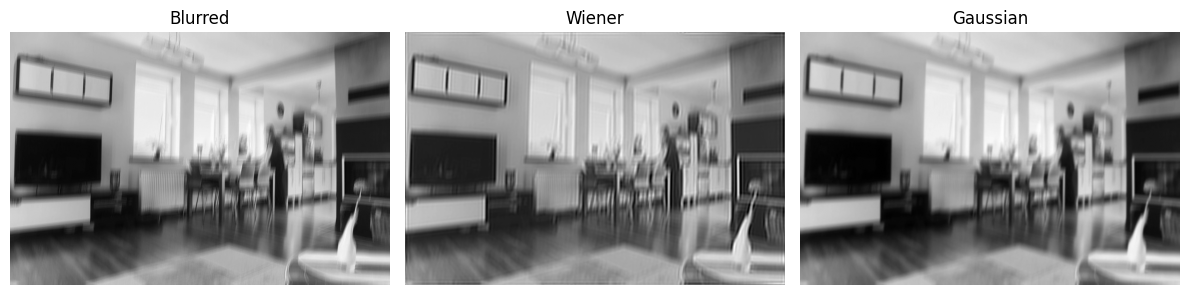

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.restoration import wiener

blurred_path = r"dataset/blurred/archive/val2017_blurred_deterministic"
save_path = r"results/deblur"
os.makedirs(save_path, exist_ok=True)

img_name = "000000000139.jpg"
img_path = os.path.join(blurred_path, img_name)

# read image as grayscale for first simple Wiener test
blurred_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# convert to float in range [0, 1]
blurred_float = blurred_img.astype(np.float32) / 255.0

# simple PSF kernel
psf = np.ones((5, 5), dtype=np.float32) / 25.0

# Wiener deblurring
wiener_img = wiener(blurred_float, psf, balance=0.1)

# convert back to uint8 for saving/display
wiener_uint8 = np.clip(wiener_img * 255, 0, 255).astype(np.uint8)

# save
wiener_save_path = os.path.join(save_path, "wiener_" + img_name)
cv2.imwrite(wiener_save_path, wiener_uint8)

print("Saved Wiener image to:", wiener_save_path)

# show results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(blurred_img, cmap="gray")
plt.title("Blurred")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(wiener_uint8, cmap="gray")
plt.title("Wiener")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.imread(os.path.join(save_path, "gaussian_" + img_name), cv2.IMREAD_GRAYSCALE), cmap="gray")
plt.title("Gaussian")
plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
import os
import cv2
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

original_path = r"dataset/original/val2017"
deblur_path = r"results/deblur"

img_name = "000000000139.jpg"

# load original in grayscale
original_img = cv2.imread(os.path.join(original_path, img_name), cv2.IMREAD_GRAYSCALE)

# load Gaussian and Wiener results
gaussian_img = cv2.imread(os.path.join(deblur_path, "gaussian_" + img_name), cv2.IMREAD_GRAYSCALE)
wiener_img = cv2.imread(os.path.join(deblur_path, "wiener_" + img_name), cv2.IMREAD_GRAYSCALE)

# metrics
gaussian_psnr = psnr(original_img, gaussian_img, data_range=255)
gaussian_ssim = ssim(original_img, gaussian_img, data_range=255)

wiener_psnr = psnr(original_img, wiener_img, data_range=255)
wiener_ssim = ssim(original_img, wiener_img, data_range=255)

print("Gaussian PSNR:", round(gaussian_psnr, 3))
print("Gaussian SSIM:", round(gaussian_ssim, 3))
print("Wiener PSNR:", round(wiener_psnr, 3))
print("Wiener SSIM:", round(wiener_ssim, 3))

Gaussian PSNR: 24.97
Gaussian SSIM: 0.729
Wiener PSNR: 24.615
Wiener SSIM: 0.698


In [7]:
import os
import cv2
import numpy as np
from skimage.restoration import wiener
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm

blurred_path = r"dataset/blurred/archive/val2017_blurred_deterministic"
original_path = r"dataset/original/val2017"
save_path = r"results/deblur"

os.makedirs(save_path, exist_ok=True)

image_list = sorted(os.listdir(blurred_path))[:20]  # take 20 images

gaussian_psnr_list = []
gaussian_ssim_list = []

wiener_psnr_list = []
wiener_ssim_list = []

for img_name in tqdm(image_list):
    blurred_img_path = os.path.join(blurred_path, img_name)
    original_img_path = os.path.join(original_path, img_name)

    # load images
    blurred = cv2.imread(blurred_img_path, cv2.IMREAD_GRAYSCALE)
    original = cv2.imread(original_img_path, cv2.IMREAD_GRAYSCALE)

    if blurred is None or original is None:
        continue

    # Gaussian
    gaussian = cv2.GaussianBlur(blurred, (5,5), 0)

    # Wiener
    blurred_float = blurred.astype(np.float32) / 255.0
    psf = np.ones((5,5), dtype=np.float32) / 25.0
    wiener_img = wiener(blurred_float, psf, balance=0.1)
    wiener_uint8 = np.clip(wiener_img * 255, 0, 255).astype(np.uint8)

    # metrics
    gaussian_psnr_list.append(psnr(original, gaussian, data_range=255))
    gaussian_ssim_list.append(ssim(original, gaussian, data_range=255))

    wiener_psnr_list.append(psnr(original, wiener_uint8, data_range=255))
    wiener_ssim_list.append(ssim(original, wiener_uint8, data_range=255))

# averages
print("\n=== AVERAGE RESULTS ===")
print("Gaussian PSNR:", round(np.mean(gaussian_psnr_list), 3))
print("Gaussian SSIM:", round(np.mean(gaussian_ssim_list), 3))

print("Wiener PSNR:", round(np.mean(wiener_psnr_list), 3))
print("Wiener SSIM:", round(np.mean(wiener_ssim_list), 3))

100%|██████████| 20/20 [00:02<00:00,  7.44it/s]


=== AVERAGE RESULTS ===
Gaussian PSNR: 23.009
Gaussian SSIM: 0.65
Wiener PSNR: 22.802
Wiener SSIM: 0.642


In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.restoration import wiener

blurred_path = r"dataset/blurred/archive/val2017_blurred_deterministic"
original_path = r"dataset/original/val2017"
save_vis_path = r"results/deblur/visuals"

os.makedirs(save_vis_path, exist_ok=True)

image_list = sorted(os.listdir(blurred_path))[:5]

for img_name in image_list:
    blurred = cv2.imread(os.path.join(blurred_path, img_name), cv2.IMREAD_GRAYSCALE)
    original = cv2.imread(os.path.join(original_path, img_name), cv2.IMREAD_GRAYSCALE)

    if blurred is None or original is None:
        continue

    # Gaussian
    gaussian = cv2.GaussianBlur(blurred, (5, 5), 0)

    # Wiener
    blurred_float = blurred.astype(np.float32) / 255.0
    psf = np.ones((5, 5), dtype=np.float32) / 25.0
    wiener_img = wiener(blurred_float, psf, balance=0.1)
    wiener_uint8 = np.clip(wiener_img * 255, 0, 255).astype(np.uint8)

    # Plot and save
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(original, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(blurred, cmap="gray")
    plt.title("Blurred")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(gaussian, cmap="gray")
    plt.title("Gaussian")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(wiener_uint8, cmap="gray")
    plt.title("Wiener")
    plt.axis("off")

    plt.tight_layout()
    save_file = os.path.join(save_vis_path, f"comparison_{img_name}")
    plt.savefig(save_file, bbox_inches="tight")
    plt.close()

print("Saved visual comparisons to:", save_vis_path)

Saved visual comparisons to: results/deblur/visuals


In [9]:
import os
import cv2
import numpy as np
from skimage.restoration import wiener
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

blurred_path = r"dataset/blurred/archive/val2017_blurred_deterministic"
original_path = r"dataset/original/val2017"

image_list = sorted(os.listdir(blurred_path))[:10]  # use 10 images for tuning

balance_values = [0.01, 0.05, 0.1, 0.2]
psf_sizes = [3, 5, 7]

best_score = 0
best_params = None

for b in balance_values:
    for k in psf_sizes:
        psnr_list = []
        ssim_list = []

        psf = np.ones((k, k), dtype=np.float32) / (k * k)

        for img_name in image_list:
            blurred = cv2.imread(os.path.join(blurred_path, img_name), cv2.IMREAD_GRAYSCALE)
            original = cv2.imread(os.path.join(original_path, img_name), cv2.IMREAD_GRAYSCALE)

            if blurred is None or original is None:
                continue

            blurred_float = blurred.astype(np.float32) / 255.0
            wiener_img = wiener(blurred_float, psf, balance=b)
            wiener_uint8 = np.clip(wiener_img * 255, 0, 255).astype(np.uint8)

            psnr_list.append(psnr(original, wiener_uint8, data_range=255))
            ssim_list.append(ssim(original, wiener_uint8, data_range=255))

        avg_psnr = np.mean(psnr_list)
        avg_ssim = np.mean(ssim_list)

        score = avg_psnr + avg_ssim  # simple combined score

        print(f"balance={b}, psf={k}x{k} → PSNR={avg_psnr:.3f}, SSIM={avg_ssim:.3f}")

        if score > best_score:
            best_score = score
            best_params = (b, k)

print("\nBest parameters:", best_params)

balance=0.01, psf=3x3 → PSNR=22.339, SSIM=0.617
balance=0.01, psf=5x5 → PSNR=21.087, SSIM=0.535
balance=0.01, psf=7x7 → PSNR=18.939, SSIM=0.388
balance=0.05, psf=3x3 → PSNR=22.536, SSIM=0.623
balance=0.05, psf=5x5 → PSNR=22.085, SSIM=0.593
balance=0.05, psf=7x7 → PSNR=21.023, SSIM=0.512
balance=0.1, psf=3x3 → PSNR=22.540, SSIM=0.620
balance=0.1, psf=5x5 → PSNR=22.257, SSIM=0.601
balance=0.1, psf=7x7 → PSNR=21.559, SSIM=0.545
balance=0.2, psf=3x3 → PSNR=22.516, SSIM=0.615
balance=0.2, psf=5x5 → PSNR=22.341, SSIM=0.602
balance=0.2, psf=7x7 → PSNR=21.897, SSIM=0.564

Best parameters: (0.1, 3)


In [10]:
import os
import cv2
import numpy as np
from skimage.restoration import wiener
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm

blurred_path = r"dataset/blurred/archive/val2017_blurred_deterministic"
original_path = r"dataset/original/val2017"

image_list = sorted(os.listdir(blurred_path))[:20]

gaussian_psnr_list = []
gaussian_ssim_list = []
wiener_psnr_list = []
wiener_ssim_list = []

# final tuned Wiener settings
balance_value = 0.1
psf_size = 3
psf = np.ones((psf_size, psf_size), dtype=np.float32) / (psf_size * psf_size)

for img_name in tqdm(image_list):
    blurred = cv2.imread(os.path.join(blurred_path, img_name), cv2.IMREAD_GRAYSCALE)
    original = cv2.imread(os.path.join(original_path, img_name), cv2.IMREAD_GRAYSCALE)

    if blurred is None or original is None:
        continue

    # Gaussian baseline
    gaussian = cv2.GaussianBlur(blurred, (5, 5), 0)

    # tuned Wiener
    blurred_float = blurred.astype(np.float32) / 255.0
    wiener_img = wiener(blurred_float, psf, balance=balance_value)
    wiener_uint8 = np.clip(wiener_img * 255, 0, 255).astype(np.uint8)

    # metrics
    gaussian_psnr_list.append(psnr(original, gaussian, data_range=255))
    gaussian_ssim_list.append(ssim(original, gaussian, data_range=255))

    wiener_psnr_list.append(psnr(original, wiener_uint8, data_range=255))
    wiener_ssim_list.append(ssim(original, wiener_uint8, data_range=255))

print("\n=== FINAL TASK 2 RESULTS ===")
print("Gaussian PSNR:", round(np.mean(gaussian_psnr_list), 3))
print("Gaussian SSIM:", round(np.mean(gaussian_ssim_list), 3))
print("Wiener PSNR:", round(np.mean(wiener_psnr_list), 3))
print("Wiener SSIM:", round(np.mean(wiener_ssim_list), 3))

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:02<00:00,  7.44it/s]


=== FINAL TASK 2 RESULTS ===
Gaussian PSNR: 23.009
Gaussian SSIM: 0.65
Wiener PSNR: 23.147
Wiener SSIM: 0.663



image 1/1 c:\Users\Aakash\project\dataset\blurred\archive\val2017_blurred_deterministic\000000000139.jpg: 448x640 1 person, 2 chairs, 2 tvs, 142.4ms
Speed: 3.6ms preprocess, 142.4ms inference, 39.3ms postprocess per image at shape (1, 3, 448, 640)


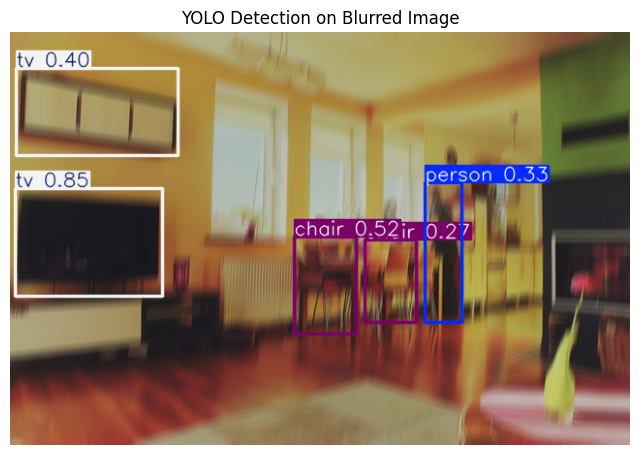

In [11]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os

# load pretrained YOLO model
model = YOLO("yolov8n.pt")

blurred_path = r"dataset/blurred/archive/val2017_blurred_deterministic"
img_name = "000000000139.jpg"
img_path = os.path.join(blurred_path, img_name)

# run detection
results = model(img_path)

# plot detection result
annotated = results[0].plot()

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title("YOLO Detection on Blurred Image")
plt.axis("off")
plt.show()

In [12]:
boxes = results[0].boxes

print("Number of detections:", len(boxes))

for i, box in enumerate(boxes[:5]):
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    print(f"Detection {i+1}: class={cls_id}, confidence={conf:.3f}")

Number of detections: 5
Detection 1: class=62, confidence=0.846
Detection 2: class=56, confidence=0.518
Detection 3: class=62, confidence=0.397
Detection 4: class=0, confidence=0.326
Detection 5: class=56, confidence=0.269


Blurred loaded: True
Wiener loaded: True

0: 448x640 1 person, 2 chairs, 2 tvs, 20.2ms
Speed: 12.7ms preprocess, 20.2ms inference, 3.0ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 3 chairs, 1 tv, 1 vase, 17.5ms
Speed: 2.5ms preprocess, 17.5ms inference, 2.5ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 2 chairs, 1 tv, 1 microwave, 15.6ms
Speed: 2.9ms preprocess, 15.6ms inference, 2.7ms postprocess per image at shape (1, 3, 448, 640)


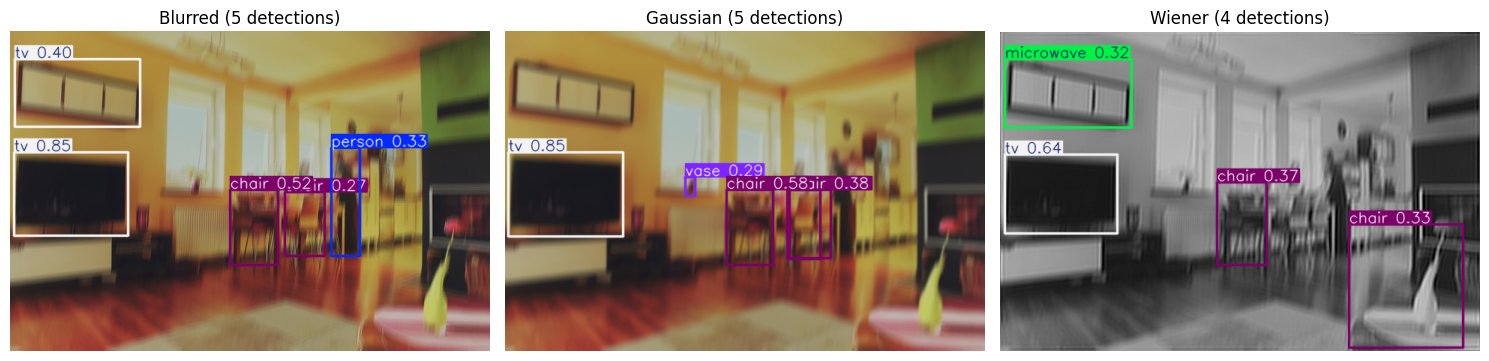

In [13]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# paths
blurred_path = r"dataset/blurred/archive/val2017_blurred_deterministic"
deblur_path = r"results/deblur"
img_name = "000000000139.jpg"

blurred_img_path = os.path.join(blurred_path, img_name)
wiener_img_path = os.path.join(deblur_path, "wiener_" + img_name)

# load model
model = YOLO("yolov8n.pt")

# load images
blurred = cv2.imread(blurred_img_path)
gaussian = cv2.GaussianBlur(blurred, (5, 5), 0)
wiener_bgr = cv2.imread(wiener_img_path)

print("Blurred loaded:", blurred is not None)
print("Wiener loaded:", wiener_bgr is not None)

# run detection
res_blur = model(blurred)[0]
res_gauss = model(gaussian)[0]
res_wiener = model(wiener_bgr)[0]

# annotated outputs
ann_blur = res_blur.plot()
ann_gauss = res_gauss.plot()
ann_wiener = res_wiener.plot()

# show results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(ann_blur, cv2.COLOR_BGR2RGB))
plt.title(f"Blurred ({len(res_blur.boxes)} detections)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(ann_gauss, cv2.COLOR_BGR2RGB))
plt.title(f"Gaussian ({len(res_gauss.boxes)} detections)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(ann_wiener, cv2.COLOR_BGR2RGB))
plt.title(f"Wiener ({len(res_wiener.boxes)} detections)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
def avg_conf(result):
    if len(result.boxes) == 0:
        return 0.0
    return float(result.boxes.conf.mean())

print("Blurred detections:", len(res_blur.boxes), "Avg confidence:", round(avg_conf(res_blur), 3))
print("Gaussian detections:", len(res_gauss.boxes), "Avg confidence:", round(avg_conf(res_gauss), 3))
print("Wiener detections:", len(res_wiener.boxes), "Avg confidence:", round(avg_conf(res_wiener), 3))

Blurred detections: 5 Avg confidence: 0.471
Gaussian detections: 5 Avg confidence: 0.495
Wiener detections: 4 Avg confidence: 0.413


In [15]:
import os
import cv2
import numpy as np
from ultralytics import YOLO
from tqdm import tqdm

# paths
blurred_path = r"dataset/blurred/archive/val2017_blurred_deterministic"
wiener_path = r"results/deblur"

# load model
model = YOLO("yolov8n.pt")

image_list = sorted(os.listdir(blurred_path))[:10]

blur_counts = []
gauss_counts = []
wiener_counts = []

blur_confs = []
gauss_confs = []
wiener_confs = []

def avg_conf(result):
    if len(result.boxes) == 0:
        return 0.0
    return float(result.boxes.conf.mean())

for img_name in tqdm(image_list):
    blurred_img_path = os.path.join(blurred_path, img_name)
    wiener_img_path = os.path.join(wiener_path, "wiener_" + img_name)

    blurred = cv2.imread(blurred_img_path)
    if blurred is None:
        continue

    gaussian = cv2.GaussianBlur(blurred, (5, 5), 0)

    # if saved Wiener image does not exist yet, skip it for now
    if not os.path.exists(wiener_img_path):
        continue

    wiener_img = cv2.imread(wiener_img_path)
    if wiener_img is None:
        continue

    # detection
    res_blur = model(blurred, verbose=False)[0]
    res_gauss = model(gaussian, verbose=False)[0]
    res_wiener = model(wiener_img, verbose=False)[0]

    blur_counts.append(len(res_blur.boxes))
    gauss_counts.append(len(res_gauss.boxes))
    wiener_counts.append(len(res_wiener.boxes))

    blur_confs.append(avg_conf(res_blur))
    gauss_confs.append(avg_conf(res_gauss))
    wiener_confs.append(avg_conf(res_wiener))

print("\n=== TASK 3 MULTI-IMAGE RESULTS ===")
print("Blurred   -> Avg detections:", round(np.mean(blur_counts), 3), "Avg confidence:", round(np.mean(blur_confs), 3))
print("Gaussian  -> Avg detections:", round(np.mean(gauss_counts), 3), "Avg confidence:", round(np.mean(gauss_confs), 3))
print("Wiener    -> Avg detections:", round(np.mean(wiener_counts), 3), "Avg confidence:", round(np.mean(wiener_confs), 3))

100%|██████████| 10/10 [00:00<00:00, 42.88it/s]


=== TASK 3 MULTI-IMAGE RESULTS ===
Blurred   -> Avg detections: 5.0 Avg confidence: 0.471
Gaussian  -> Avg detections: 5.0 Avg confidence: 0.495
Wiener    -> Avg detections: 4.0 Avg confidence: 0.413


In [16]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

blurred_path = r"dataset/blurred/archive/val2017_blurred_deterministic"
wiener_path = r"results/deblur"
save_path = r"results/detection"
os.makedirs(save_path, exist_ok=True)

model = YOLO("yolov8n.pt")

image_list = sorted(os.listdir(blurred_path))[:5]

for img_name in image_list:
    blurred_img_path = os.path.join(blurred_path, img_name)
    wiener_img_path = os.path.join(wiener_path, "wiener_" + img_name)

    blurred = cv2.imread(blurred_img_path)
    if blurred is None:
        continue

    gaussian = cv2.GaussianBlur(blurred, (5, 5), 0)

    if not os.path.exists(wiener_img_path):
        continue

    wiener_img = cv2.imread(wiener_img_path)
    if wiener_img is None:
        continue

    res_blur = model(blurred, verbose=False)[0]
    res_gauss = model(gaussian, verbose=False)[0]
    res_wiener = model(wiener_img, verbose=False)[0]

    ann_blur = res_blur.plot()
    ann_gauss = res_gauss.plot()
    ann_wiener = res_wiener.plot()

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(ann_blur, cv2.COLOR_BGR2RGB))
    plt.title(f"Blurred ({len(res_blur.boxes)} det)")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(ann_gauss, cv2.COLOR_BGR2RGB))
    plt.title(f"Gaussian ({len(res_gauss.boxes)} det)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(ann_wiener, cv2.COLOR_BGR2RGB))
    plt.title(f"Wiener ({len(res_wiener.boxes)} det)")
    plt.axis("off")

    plt.tight_layout()
    save_file = os.path.join(save_path, f"detection_compare_{img_name}")
    plt.savefig(save_file, bbox_inches="tight")
    plt.close()

print("Saved detection comparison images to:", save_path)

Saved detection comparison images to: results/detection


In [17]:
import os
import shutil

blurred_path = r"dataset/blurred/archive/val2017_blurred_deterministic"
original_path = r"dataset/original/val2017"
processed_path = r"dataset/processed"

# delete old processed folder if it exists
if os.path.exists(processed_path):
    shutil.rmtree(processed_path)

# create folders
splits = ["train", "val", "test"]
types = ["blurred", "original"]

for split in splits:
    for t in types:
        os.makedirs(os.path.join(processed_path, split, t), exist_ok=True)

# choose 300 images total
image_list = sorted(os.listdir(blurred_path))[:300]

train_imgs = image_list[:180]
val_imgs = image_list[180:240]
test_imgs = image_list[240:300]

split_map = {
    "train": train_imgs,
    "val": val_imgs,
    "test": test_imgs
}

# copy files
for split, imgs in split_map.items():
    for img_name in imgs:
        blurred_src = os.path.join(blurred_path, img_name)
        original_src = os.path.join(original_path, img_name)

        blurred_dst = os.path.join(processed_path, split, "blurred", img_name)
        original_dst = os.path.join(processed_path, split, "original", img_name)

        if os.path.exists(blurred_src):
            shutil.copy2(blurred_src, blurred_dst)
        if os.path.exists(original_src):
            shutil.copy2(original_src, original_dst)

print("Dataset split created successfully.")

for split in splits:
    blurred_count = len(os.listdir(os.path.join(processed_path, split, "blurred")))
    original_count = len(os.listdir(os.path.join(processed_path, split, "original")))
    print(f"{split}: blurred={blurred_count}, original={original_count}")

Dataset split created successfully.
train: blurred=180, original=180
val: blurred=60, original=60
test: blurred=60, original=60


In [18]:
import cv2
import numpy as np

def wiener_deblur_color(img_bgr, kernel_size=5, K=0.05, pad=50):
    if img_bgr is None:
        return None

    img_pad = cv2.copyMakeBorder(
        img_bgr, pad, pad, pad, pad,
        borderType=cv2.BORDER_REFLECT
    )
    h, w, _ = img_pad.shape

    psf = np.ones((kernel_size, kernel_size), dtype=np.float32)
    psf /= psf.sum()

    psf_padded = np.zeros((h, w), dtype=np.float32)
    cy, cx = h // 2, w // 2
    ky, kx = kernel_size // 2, kernel_size // 2
    psf_padded[cy - ky:cy + ky + 1, cx - kx:cx + kx + 1] = psf
    psf_padded = np.fft.ifftshift(psf_padded)

    H = np.fft.fft2(psf_padded)
    H_conj = np.conj(H)

    output_channels = []
    for ch in range(3):
        channel = img_pad[:, :, ch].astype(np.float32) / 255.0
        G = np.fft.fft2(channel)

        F_hat = (H_conj / (np.abs(H) ** 2 + K)) * G
        restored = np.real(np.fft.ifft2(F_hat))
        restored = np.clip(restored, 0, 1)

        restored_uint8 = (restored * 255).astype(np.uint8)

        blurred_back = cv2.GaussianBlur(restored_uint8, (3, 3), 0)
        sharpened = cv2.addWeighted(restored_uint8, 1.5, blurred_back, -0.5, 0)
        sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

        output_channels.append(sharpened)

    out = cv2.merge(output_channels)
    out = out[pad:-pad, pad:-pad]
    return out

In [13]:
import os
import cv2

base = r"C:\Users\Aakash\project\dataset\processed"
blurred_dir = os.path.join(base, "train", "blurred")

first_image = sorted(os.listdir(blurred_dir))[0]
img = cv2.imread(os.path.join(blurred_dir, first_image))

out = wiener_deblur_color(img, kernel_size=5, K=0.05, pad=50)

cv2.imwrite(r"C:\Users\Aakash\project\test_output.jpg", out)
print("Done - open test_output.jpg")

Done - open test_output.jpg


In [19]:
import os
import cv2
from tqdm import tqdm

processed_path = r"dataset/processed"
splits = ["train", "val", "test"]

for split in splits:
    blurred_dir = os.path.join(processed_path, split, "blurred")
    deblurred_dir = os.path.join(processed_path, split, "deblurred")

    # clear old deblurred files
    if os.path.exists(deblurred_dir):
        for f in os.listdir(deblurred_dir):
            os.remove(os.path.join(deblurred_dir, f))
    else:
        os.makedirs(deblurred_dir)

    image_list = sorted(os.listdir(blurred_dir))

    for img_name in tqdm(image_list, desc=f"Processing {split}"):
        img_path = os.path.join(blurred_dir, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        out = wiener_deblur_color(img, kernel_size=5, K=0.05, pad=50)

        save_path = os.path.join(deblurred_dir, img_name)
        cv2.imwrite(save_path, out)

print("\nDeblurred dataset created successfully.")

for split in splits:
    count = len(os.listdir(os.path.join(processed_path, split, "deblurred")))
    print(f"{split}: deblurred={count}")

Processing train:   0%|          | 0/180 [00:00<?, ?it/s]

Processing test: 100%|██████████| 60/60 [00:13<00:00,  4.33it/s]


Deblurred dataset created successfully.
train: deblurred=180
val: deblurred=60
test: deblurred=60


In [20]:
import os
import json

annotations_file = r"dataset/annotations/instances_val2017.json"
processed_path = r"dataset/processed"

selected_filenames = set()

for split in ["train", "val", "test"]:
    split_dir = os.path.join(processed_path, split, "blurred")
    for fname in os.listdir(split_dir):
        selected_filenames.add(fname)

print("Total selected filenames:", len(selected_filenames))

with open(annotations_file, "r", encoding="utf-8") as f:
    coco_data = json.load(f)

selected_images = [img for img in coco_data["images"] if img["file_name"] in selected_filenames]
selected_image_ids = {img["id"] for img in selected_images}

selected_annotations = [
    ann for ann in coco_data["annotations"]
    if ann["image_id"] in selected_image_ids
]

subset_data = {
    "info": coco_data.get("info", {}),
    "licenses": coco_data.get("licenses", []),
    "images": selected_images,
    "annotations": selected_annotations,
    "categories": coco_data["categories"]
}

subset_annotation_path = os.path.join(processed_path, "subset_instances_val2017.json")

with open(subset_annotation_path, "w", encoding="utf-8") as f:
    json.dump(subset_data, f)

print("Saved subset annotations to:", subset_annotation_path)
print("Number of images in subset:", len(selected_images))
print("Number of annotations in subset:", len(selected_annotations))
print("Number of categories:", len(subset_data["categories"]))

Total selected filenames: 300
Saved subset annotations to: dataset/processed\subset_instances_val2017.json
Number of images in subset: 300
Number of annotations in subset: 2168
Number of categories: 80


In [21]:
import os
import json

processed_path = r"dataset/processed"
subset_json_path = os.path.join(processed_path, "subset_instances_val2017.json")

with open(subset_json_path, "r", encoding="utf-8") as f:
    coco = json.load(f)

# image_id -> file info
image_id_to_info = {}
for img in coco["images"]:
    image_id_to_info[img["id"]] = {
        "file_name": img["file_name"],
        "width": img["width"],
        "height": img["height"]
    }

# COCO category id -> YOLO class index
category_ids = sorted([cat["id"] for cat in coco["categories"]])
cat_id_to_yolo = {cat_id: idx for idx, cat_id in enumerate(category_ids)}

# filenames by split
split_to_filenames = {}
for split in ["train", "val", "test"]:
    split_dir = os.path.join(processed_path, split, "deblurred")
    split_to_filenames[split] = set(os.listdir(split_dir))

# recreate labels folders cleanly
for split in ["train", "val", "test"]:
    labels_dir = os.path.join(processed_path, split, "labels")
    if os.path.exists(labels_dir):
        for f in os.listdir(labels_dir):
            os.remove(os.path.join(labels_dir, f))
    else:
        os.makedirs(labels_dir, exist_ok=True)

# create empty txt files for every image
for split in ["train", "val", "test"]:
    for fname in split_to_filenames[split]:
        txt_name = os.path.splitext(fname)[0] + ".txt"
        txt_path = os.path.join(processed_path, split, "labels", txt_name)
        open(txt_path, "w").close()

# write YOLO labels
for ann in coco["annotations"]:
    image_id = ann["image_id"]
    if image_id not in image_id_to_info:
        continue

    info = image_id_to_info[image_id]
    fname = info["file_name"]

    split_name = None
    for split in ["train", "val", "test"]:
        if fname in split_to_filenames[split]:
            split_name = split
            break

    if split_name is None:
        continue

    width = info["width"]
    height = info["height"]

    x, y, w, h = ann["bbox"]

    x_center = (x + w / 2) / width
    y_center = (y + h / 2) / height
    w_norm = w / width
    h_norm = h / height

    class_id = cat_id_to_yolo[ann["category_id"]]

    txt_name = os.path.splitext(fname)[0] + ".txt"
    txt_path = os.path.join(processed_path, split_name, "labels", txt_name)

    with open(txt_path, "a", encoding="utf-8") as f:
        f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n")

# count check
for split in ["train", "val", "test"]:
    labels_dir = os.path.join(processed_path, split, "labels")
    print(f"{split}: labels={len(os.listdir(labels_dir))}")

train: labels=180
val: labels=60
test: labels=60


In [22]:
import os
import json

processed_path = r"dataset/processed"
subset_json_path = os.path.join(processed_path, "subset_instances_val2017.json")

with open(subset_json_path, "r", encoding="utf-8") as f:
    coco = json.load(f)

# image_id -> file info
image_id_to_info = {}
for img in coco["images"]:
    image_id_to_info[img["id"]] = {
        "file_name": img["file_name"],
        "width": img["width"],
        "height": img["height"]
    }

# COCO category id -> YOLO class index
category_ids = sorted([cat["id"] for cat in coco["categories"]])
cat_id_to_yolo = {cat_id: idx for idx, cat_id in enumerate(category_ids)}

# filenames by split
split_to_filenames = {}
for split in ["train", "val", "test"]:
    split_dir = os.path.join(processed_path, split, "deblurred")
    split_to_filenames[split] = set(os.listdir(split_dir))

# recreate labels folders cleanly
for split in ["train", "val", "test"]:
    labels_dir = os.path.join(processed_path, split, "labels")
    if os.path.exists(labels_dir):
        for f in os.listdir(labels_dir):
            os.remove(os.path.join(labels_dir, f))
    else:
        os.makedirs(labels_dir, exist_ok=True)

# create empty txt files for every image
for split in ["train", "val", "test"]:
    for fname in split_to_filenames[split]:
        txt_name = os.path.splitext(fname)[0] + ".txt"
        txt_path = os.path.join(processed_path, split, "labels", txt_name)
        open(txt_path, "w").close()

# write YOLO labels
for ann in coco["annotations"]:
    image_id = ann["image_id"]
    if image_id not in image_id_to_info:
        continue

    info = image_id_to_info[image_id]
    fname = info["file_name"]

    split_name = None
    for split in ["train", "val", "test"]:
        if fname in split_to_filenames[split]:
            split_name = split
            break

    if split_name is None:
        continue

    width = info["width"]
    height = info["height"]

    x, y, w, h = ann["bbox"]

    x_center = (x + w / 2) / width
    y_center = (y + h / 2) / height
    w_norm = w / width
    h_norm = h / height

    class_id = cat_id_to_yolo[ann["category_id"]]

    txt_name = os.path.splitext(fname)[0] + ".txt"
    txt_path = os.path.join(processed_path, split_name, "labels", txt_name)

    with open(txt_path, "a", encoding="utf-8") as f:
        f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n")

# count check
for split in ["train", "val", "test"]:
    labels_dir = os.path.join(processed_path, split, "labels")
    print(f"{split}: labels={len(os.listdir(labels_dir))}")

train: labels=180
val: labels=60
test: labels=60


In [18]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: False


In [1]:
import sys
print(sys.executable)

c:\Program Files\Python313\python.exe


In [3]:
import importlib.util
print(importlib.util.find_spec("ultralytics"))

ModuleSpec(name='ultralytics', loader=<_frozen_importlib_external.SourceFileLoader object at 0x000001DB539D71D0>, origin='C:\\Users\\Aakash\\AppData\\Roaming\\Python\\Python313\\site-packages\\ultralytics\\__init__.py', submodule_search_locations=['C:\\Users\\Aakash\\AppData\\Roaming\\Python\\Python313\\site-packages\\ultralytics'])


In [7]:
import sys
print(sys.executable)

c:\Program Files\Python313\python.exe


In [8]:
import sys
!"{sys.executable}" -m pip uninstall -y torch torchvision torchaudio
!"{sys.executable}" -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchvision 0.26.0
Uninstalling torchvision-0.26.0:
  Successfully uninstalled torchvision-0.26.0


You can safely remove it manually.


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu118
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 8.0 MB/s eta 0:05:51
   ---------------------------------------- 0.0/2.8 GB 13.7 MB/s eta 0:03:25
   ---------------------------------------- 0.0/2.8 GB 14.4 MB/s eta 0:03:15
   ---------------------------------------- 0.0/2.8 GB 13.9 MB/s eta 0:03:23
   ---------------------------------------- 0.0/2.8 GB 15.4 MB/s eta 0:03:02
   ---------------------------------------- 0.0/2.8 GB 14.8 MB/s eta 0:03:10
   ---------------------------------------- 0.0/2.8 GB 17.1 MB/s eta 0:02:44
   ---------------------------------------- 0.0/2.8 GB 18.1 MB/s eta 0:02:34
   ---------------------------------------- 0.0/2.8 GB 17.5 MB/s eta 0:02:39
    --------------------------------------- 0.0/2.8 GB 19.3 MB/s eta 0:02:25
    ---------------------

In [1]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.7.1+cu118
CUDA available: True
CUDA device count: 1
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [6]:
import os

print("Current working directory:", os.getcwd())
print("YAML exists:", os.path.exists(r"dataset/processed/dataset.yaml"))
print("Processed folder exists:", os.path.exists(r"dataset/processed"))

Current working directory: c:\Users\Aakash\project
YAML exists: False
Processed folder exists: True


In [15]:
import os
import json
import yaml

processed_path = r"dataset/processed"
subset_json_path = os.path.join(processed_path, "subset_instances_val2017.json")
yaml_path = os.path.join(processed_path, "dataset.yaml")

with open(subset_json_path, "r", encoding="utf-8") as f:
    coco = json.load(f)

categories = sorted(coco["categories"], key=lambda x: x["id"])
class_names = [cat["name"] for cat in categories]

data_yaml = {
    "path": os.path.abspath(processed_path),
    "train": "train/deblurred",
    "val": "val/deblurred",
    "test": "test/deblurred",
    "names": {i: name for i, name in enumerate(class_names)}
}

with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print("Saved dataset YAML to:", yaml_path)
print("Exists now:", os.path.exists(yaml_path))

Saved dataset YAML to: dataset/processed\dataset.yaml
Exists now: True


claude

In [22]:
import os
import json
import yaml

processed_path = r"C:\Users\Aakash\project\dataset\processed"
subset_json_path = os.path.join(processed_path, "subset_instances_val2017.json")
yaml_path = os.path.join(processed_path, "dataset.yaml")

with open(subset_json_path, "r", encoding="utf-8") as f:
    coco = json.load(f)

categories = sorted(coco["categories"], key=lambda x: x["id"])
class_names = [cat["name"] for cat in categories]

# ✅ YOLO auto-finds labels/ when images folder is literally named "images"
# So we create symlinks or just rename — easiest: point yaml to original/
# and add label_dir override using ultralytics' supported 'path' trick.
# Best solution: restructure on-the-fly using the yaml below.

data_yaml = {
    "path": processed_path.replace("\\", "/"),
    "train": "train/original",
    "val":   "val/original",
    "test":  "test/original",
    "names": {i: name for i, name in enumerate(class_names)}
}

with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print("✅ YAML saved to:", yaml_path)
print(f"   Classes ({len(class_names)}):", class_names[:5], "...")

# ✅ Now rename original/ → images/ and labels stays as labels/
# YOLO replaces 'images' with 'labels' to find .txt files
import shutil

for split in ["train", "val", "test"]:
    src = os.path.join(processed_path, split, "original")
    dst = os.path.join(processed_path, split, "images")

    if os.path.exists(src) and not os.path.exists(dst):
        os.rename(src, dst)
        print(f"✅ Renamed {split}/original → {split}/images")
    elif os.path.exists(dst):
        print(f"ℹ️  {split}/images already exists, skipping rename")
    else:
        print(f"❌ {split}/original not found!")

# Update YAML to use images/ now
data_yaml["train"] = "train/images"
data_yaml["val"]   = "val/images"
data_yaml["test"]  = "test/images"

with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print("\n✅ YAML updated to use images/ folders")

# ✅ Final verification
print("\n=== PATH VERIFICATION ===")
for split in ["train", "val", "test"]:
    for sub in ["images", "labels"]:
        p = os.path.join(processed_path, split, sub)
        exists = os.path.exists(p)
        count  = len(os.listdir(p)) if exists else 0
        status = "✅" if exists and count > 0 else "❌"
        print(f"  {status} {split}/{sub}: {count} files")

✅ YAML saved to: C:\Users\Aakash\project\dataset\processed\dataset.yaml
   Classes (80): ['person', 'bicycle', 'car', 'motorcycle', 'airplane'] ...
✅ Renamed train/original → train/images
✅ Renamed val/original → val/images
✅ Renamed test/original → test/images

✅ YAML updated to use images/ folders

=== PATH VERIFICATION ===
  ✅ train/images: 180 files
  ✅ train/labels: 180 files
  ✅ val/images: 60 files
  ✅ val/labels: 60 files
  ✅ test/images: 60 files
  ✅ test/labels: 60 files


In [23]:
pip install ultralytics==8.4.33

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [27]:
import os

processed_path = r"C:\Users\Aakash\project\dataset\processed"

print("=== LABEL DIAGNOSTIC ===\n")
for split in ["train", "val", "test"]:
    label_dir = os.path.join(processed_path, split, "labels")
    img_dir   = os.path.join(processed_path, split, "images")  # or original/

    # Check labels
    if os.path.exists(label_dir):
        txts = [f for f in os.listdir(label_dir) if f.endswith(".txt")]
        empty = [f for f in txts if os.path.getsize(os.path.join(label_dir, f)) == 0]
        print(f"[{split}/labels] {len(txts)} .txt files | {len(empty)} empty")
        # Show sample content
        if txts:
            sample = os.path.join(label_dir, txts[0])
            with open(sample) as f:
                content = f.read().strip()
            print(f"  Sample ({txts[0]}): '{content[:80]}'")
    else:
        print(f"[{split}/labels] ❌ FOLDER MISSING")

    # Check image/label name match
    if os.path.exists(label_dir) and os.path.exists(img_dir):
        imgs = {os.path.splitext(f)[0] for f in os.listdir(img_dir)}
        lbls = {os.path.splitext(f)[0] for f in os.listdir(label_dir) if f.endswith(".txt")}
        matched = imgs & lbls
        print(f"  Image-label matches: {len(matched)} / {len(imgs)} images\n")

=== LABEL DIAGNOSTIC ===

[train/labels] 180 .txt files | 0 empty
  Sample (000000000139.txt): '58 0.389578 0.416103 0.038594 0.163146
62 0.127641 0.505153 0.233312 0.222700
62'
  Image-label matches: 180 / 180 images

[val/labels] 60 .txt files | 0 empty
  Sample (000000018193.txt): '56 0.332016 0.617979 0.576406 0.723583
52 0.422938 0.371708 0.059000 0.075333
0 '
  Image-label matches: 60 / 60 images

[test/labels] 60 .txt files | 1 empty
  Sample (000000025057.txt): '39 0.652945 0.317178 0.025672 0.115808
29 0.589219 0.390328 0.140937 0.175269
0 '
  Image-label matches: 60 / 60 images



In [5]:
import sys
print(sys.executable)

c:\Program Files\Python313\python.exe


In [7]:
!"{sys.executable}" -m pip install pandas

Defaulting to user installation because normal site-packages is not writeable
  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl (9.7 MB)


In [5]:
import os
import shutil

processed_base = r"C:\Users\Aakash\project\dataset\processed"
original_master = r"C:\Users\Aakash\project\dataset\original\val2017"

for split in ["train", "val", "test"]:
    blurred_dir = os.path.join(processed_base, split, "blurred")
    original_dir = os.path.join(processed_base, split, "original")

    os.makedirs(original_dir, exist_ok=True)

    # clear old files if any
    for f in os.listdir(original_dir):
        os.remove(os.path.join(original_dir, f))

    for fname in os.listdir(blurred_dir):
        src = os.path.join(original_master, fname)
        dst = os.path.join(original_dir, fname)

        if os.path.exists(src):
            shutil.copy2(src, dst)

print("Original folders recreated successfully.")

for split in ["train", "val", "test"]:
    print(
        split,
        "original =", len(os.listdir(os.path.join(processed_base, split, "original")))
    )

Original folders recreated successfully.
train original = 180
val original = 60
test original = 60


In [8]:
import os
import shutil

src_base = r"C:\Users\Aakash\project\dataset\processed"
dst_base = r"C:\Users\Aakash\project\dataset\yolo300"

# fresh start
if os.path.exists(dst_base):
    shutil.rmtree(dst_base)

for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(dst_base, "images", split), exist_ok=True)
    os.makedirs(os.path.join(dst_base, "labels", split), exist_ok=True)

# copy ORIGINAL images and labels into standard YOLO structure
for split in ["train", "val", "test"]:
    src_img_dir = os.path.join(src_base, split, "original")
    src_lbl_dir = os.path.join(src_base, split, "labels")

    dst_img_dir = os.path.join(dst_base, "images", split)
    dst_lbl_dir = os.path.join(dst_base, "labels", split)

    for fname in os.listdir(src_img_dir):
        shutil.copy2(os.path.join(src_img_dir, fname), os.path.join(dst_img_dir, fname))

    for fname in os.listdir(src_lbl_dir):
        shutil.copy2(os.path.join(src_lbl_dir, fname), os.path.join(dst_lbl_dir, fname))

print("YOLO dataset structure created successfully.")
for split in ["train", "val", "test"]:
    print(
        split,
        "images =", len(os.listdir(os.path.join(dst_base, "images", split))),
        "labels =", len(os.listdir(os.path.join(dst_base, "labels", split)))
    )

YOLO dataset structure created successfully.
train images = 180 labels = 180
val images = 60 labels = 60
test images = 60 labels = 60


In [9]:
import os
import json
import yaml

subset_json = r"C:\Users\Aakash\project\dataset\processed\subset_instances_val2017.json"
yaml_path = r"C:\Users\Aakash\project\dataset\yolo300\dataset.yaml"

with open(subset_json, "r", encoding="utf-8") as f:
    coco = json.load(f)

categories = sorted(coco["categories"], key=lambda x: x["id"])
names = {i: cat["name"] for i, cat in enumerate(categories)}

data_yaml = {
    "path": os.path.abspath(r"C:\Users\Aakash\project\dataset\yolo300"),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": names
}

with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print("Saved:", yaml_path)
print("Exists:", os.path.exists(yaml_path))

Saved: C:\Users\Aakash\project\dataset\yolo300\dataset.yaml
Exists: True


In [11]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=r"C:\Users\Aakash\project\dataset\yolo300\dataset.yaml",
    epochs=1,
    imgsz=640,
    batch=8,
    project="runs_assignment",
    name="yolo_original_300_fixed_check",
    pretrained=True,
    verbose=True
)

Ultralytics 8.4.33  Python-3.13.4 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Aakash\project\dataset\yolo300\dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_original_300_fixed_check, nbs=64, nms=False, opset=None, optimize=

In [12]:
import pandas as pd
import os

csv_path = r"C:\Users\Aakash\project\runs\detect\runs_assignment\yolo_original_300_fixed_check\results.csv"

print("CSV exists:", os.path.exists(csv_path))

df = pd.read_csv(csv_path)
print("Columns:", list(df.columns))
print(df[["epoch", "train/box_loss", "train/cls_loss", "val/box_loss", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]].tail())

CSV exists: True
Columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
   epoch  train/box_loss  train/cls_loss  val/box_loss  metrics/mAP50(B)  \
0      1         1.25351         1.79098       1.09598           0.61271   

   metrics/mAP50-95(B)  
0              0.45253  


In [13]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=r"C:\Users\Aakash\project\dataset\yolo300\dataset.yaml",
    epochs=100,
    imgsz=640,
    batch=8,
    project="runs_assignment",
    name="yolo_original_300_FINAL",
    pretrained=True,
    verbose=True
)

Ultralytics 8.4.33  Python-3.13.4 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Aakash\project\dataset\yolo300\dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_original_300_FINAL, nbs=64, nms=False, opset=None, optimize=Fals

In [24]:
from ultralytics import YOLO
import os
import cv2
import numpy as np
from tqdm import tqdm

model = YOLO(r"C:\Users\Aakash\project\runs\detect\runs_assignment\yolo_original_300_FINAL\weights\best.pt")
blurred_path = r"dataset/processed/test/blurred"
deblurred_path = r"dataset/processed/test/deblurred"
original_path = r"dataset/processed/test/original"

image_list = sorted(os.listdir(blurred_path))[:60]

def avg_conf(result):
    if len(result.boxes) == 0:
        return 0.0
    return float(result.boxes.conf.mean())

blur_counts, blur_confs = [], []
deb_counts, deb_confs = [], []
orig_counts, orig_confs = [], []

for img_name in tqdm(image_list):
    blur_img = cv2.imread(os.path.join(blurred_path, img_name))
    deb_img = cv2.imread(os.path.join(deblurred_path, img_name))
    orig_img = cv2.imread(os.path.join(original_path, img_name))

    if blur_img is None or deb_img is None or orig_img is None:
        continue

    r_blur = model.predict(blur_img, conf=0.01, verbose=False)[0]
    r_deb = model.predict(deb_img, conf=0.01, verbose=False)[0]
    r_orig = model.predict(orig_img, conf=0.01, verbose=False)[0]

    blur_counts.append(len(r_blur.boxes))
    deb_counts.append(len(r_deb.boxes))
    orig_counts.append(len(r_orig.boxes))

    blur_confs.append(avg_conf(r_blur))
    deb_confs.append(avg_conf(r_deb))
    orig_confs.append(avg_conf(r_orig))

print("\n=== RESULTS ===")
print("Blurred   -> detections:", round(np.mean(blur_counts), 3), "confidence:", round(np.mean(blur_confs), 3))
print("Deblurred -> detections:", round(np.mean(deb_counts), 3), "confidence:", round(np.mean(deb_confs), 3))
print("Original  -> detections:", round(np.mean(orig_counts), 3), "confidence:", round(np.mean(orig_confs), 3))

100%|██████████| 60/60 [00:06<00:00,  8.65it/s]


=== RESULTS ===
Blurred   -> detections: 30.983 confidence: 0.108
Deblurred -> detections: 23.217 confidence: 0.113
Original  -> detections: 58.15 confidence: 0.161


In [17]:
import os
import cv2
import matplotlib.pyplot as plt

blurred_path = r"dataset/processed/test/blurred"
deblurred_path = r"dataset/processed/test/deblurred"
original_path = r"dataset/processed/test/original"

save_path = r"results/final_examples"
os.makedirs(save_path, exist_ok=True)

image_list = sorted(os.listdir(blurred_path))[:5]

for img_name in image_list:
    blur = cv2.imread(os.path.join(blurred_path, img_name))
    deb = cv2.imread(os.path.join(deblurred_path, img_name))
    orig = cv2.imread(os.path.join(original_path, img_name))

    if blur is None or deb is None or orig is None:
        continue

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(blur, cv2.COLOR_BGR2RGB))
    plt.title("Blurred")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(deb, cv2.COLOR_BGR2RGB))
    plt.title("Deblurred")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(save_path, f"final_{img_name}"), bbox_inches="tight")
    plt.close()

print("Saved final report images to:", save_path)
print(os.listdir(save_path))

Saved final report images to: results/final_examples
['final_000000025057.jpg', 'final_000000025096.jpg', 'final_000000025139.jpg', 'final_000000025181.jpg', 'final_000000025228.jpg']
